
Самостоятельно напишите нейронную сеть, которая поможет распознавать болезни по симптомам. Используя подготовленную базу, создайте и обучите нейронную сеть, распознающую десять категорий
заболеваний: аппендицит, гастрит, гепатит, дуоденит, колит, панкреатит, холицестит, эзофагит, энтерит, язва. Добейтесь правильного распознавания 6 и более заболеваний

Сразу обратим внимание датасет небольшой и хороших результатов добится  сложно.

Ссылка на датасет:https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip

In [ ]:
# Работа с массивами данных
import numpy as np



# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D,  Input

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.utils.class_weight import compute_class_weight


# Функции операционной системы
import os



# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

In [2]:
# Скачаем архив с симптомами болезней
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip', None, quiet=True)

'diseases.zip'

In [3]:
# Распакум архив
!unzip -o diseases.zip

Archive:  diseases.zip
   creating: dis/
  inflating: dis/Аппендицит.txt  
  inflating: dis/Гастрит.txt  
  inflating: dis/Гепатит.txt  
  inflating: dis/Дуоденит.txt  
  inflating: dis/Колит.txt      
  inflating: dis/Панкреатит.txt  
  inflating: dis/Холицестит.txt  
  inflating: dis/Эзофагит.txt  
  inflating: dis/Энтерит.txt  
  inflating: dis/Язва.txt        


In [4]:
FILE_DIR  = 'dis/'                     # Папка с текстовыми файлами

In [5]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Зададим коэффициент разделения текста на обучающую и текстовую выборки
split_coef = 0.8

# Получим списки файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    m = file_name.split('.') # Разделим имя файла и расширение
    class_name = m[0]        # Из имени файла получим название класса
    ext = m[1]               # Выделим расширение файла

    if ext=='txt':                                         # Если расширение txt то берем файл в работу
        if class_name not in CLASS_LIST:                   # Проверим, есть уже такой класс в списке
            print(f'Добавление класса "{class_name}"')     # Выведем имя нового класса
            CLASS_LIST.append(class_name)                  # Добавим новый класс в списоккласса "{class_name}"')

        cls = CLASS_LIST.index(class_name)                                        # Получим индекс (номер) нового класса
        print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')      # Сообщим о появлении нового класса

        with open(f'{FILE_DIR}/{file_name}', 'r') as f: # Откроем файл на чтение
            text = f.read()                                                       # Загрузка содержимого файла в строку
            text = text.replace('\n', ' ').split(' ')                             # Уберем символы перевода строк, получим список слов
            text_len=len(text)                                                    # Найдем количество прочитанных слов
            text_train.append(' '.join(text[:int(text_len*split_coef)]))          # Выделим часть файла в обучающую выборку
            text_test.append(' '.join(text[int(text_len*split_coef):]))           # Выделим часть файла в тестовую выборку



Добавление класса "Энтерит"
Добавление файла "Энтерит.txt" в класс "Энтерит"
Добавление класса "Дуоденит"
Добавление файла "Дуоденит.txt" в класс "Дуоденит"
Добавление класса "Язва"
Добавление файла "Язва.txt" в класс "Язва"
Добавление класса "Эзофагит"
Добавление файла "Эзофагит.txt" в класс "Эзофагит"
Добавление класса "Колит"
Добавление файла "Колит.txt" в класс "Колит"
Добавление класса "Гепатит"
Добавление файла "Гепатит.txt" в класс "Гепатит"
Добавление класса "Аппендицит"
Добавление файла "Аппендицит.txt" в класс "Аппендицит"
Добавление класса "Панкреатит"
Добавление файла "Панкреатит.txt" в класс "Панкреатит"
Добавление класса "Холицестит"
Добавление файла "Холицестит.txt" в класс "Холицестит"
Добавление класса "Гастрит"
Добавление файла "Гастрит.txt" в класс "Гастрит"


In [6]:
# Найдем получившееся количество классов
CLASS_COUNT = len(CLASS_LIST)

In [7]:
# Выведем число получившихся классов
print(CLASS_COUNT)

10


In [8]:
# Проверим загрузки: выведем начальные отрывки из каждого класса

for cls in range(CLASS_COUNT):             # Запустим цикл по числу классов
    print(f'Класс: {CLASS_LIST[cls]}')     # Выведем имя класса
    print(f'  train: {text_train[cls]}')   # Выведем фрагмент обучающей выборки
    print(f'  test : {text_test[cls]}')    # Выведем фрагмент тестовой выборки
    print()

Класс: Энтерит
  train: внезапныые боли (преимущественно в середине живота) рвота понос повышение температуры симптомы общей интоксикации сердечно-сосудистые расстройства обезвоживание организма возможны судороги  тошнота рвота понос повышение температуры тела боль в голове общая слабость бледность кожных покровов белый налет на языке вздутие живота метеоризм бурчание в животе отмечается боль в верхней части живота,вокруг пупка урчание и бурление в животе головокружение тахикардия  диарея тошнота рвота выраженное урчание в животе спастическая боль в верхней половине живота симптомы общей интоксикации организма: головная боль резкая слабость лихорадка (температура может достигать 39°С) бледность обложеность языка вздутие живота.   потеря аппетита тошнота рвота понос боли в области живота повышение температуры   водянистый понос, очень редко содержащий кровь колики боли в животе тошнота рвота  боли в животе понос тошнота рвота головные боли повышение температуры Стул – до 12-15 раз в сут

## Настройка гиперпараметров

In [46]:
# Задание параметров преобразования
VOCAB_SIZE = 10000                        # Объем словаря для токенизатора
WIN_SIZE   = 50                        # Длина отрезка текста (окна) в словах
WIN_HOP    = 2                         # Шаг окна разбиения текста на векторы
EPOCHS     = 30                           # Количество эпох обучения модели
BATCH_SIZE = 8                         # Размер батча для обучения модели

## Преобразование текстов в последовательности

In [19]:
t = Tokenizer(num_words=VOCAB_SIZE)           # Создадим токенизатор для преобразования текстов в последовательности
t.fit_on_texts(text_train)                   # Построим словарь токенизатора на обучающей выборке
items = list(t.word_index.items())
print(f'Всего слов в словаре: {len(items)}')  # Выведем количество слов в словаре токенизатора
print(f'Первые 20 слов в словаре: {items[:20]}')  # Выведем первые 20 слов в словаре токенизатора

Всего слов в словаре: 1677
Первые 20 слов в словаре: [('в', 1), ('и', 2), ('боль', 3), ('или', 4), ('рвота', 5), ('тошнота', 6), ('боли', 7), ('живота', 8), ('животе', 9), ('при', 10), ('после', 11), ('с', 12), ('области', 13), ('слабость', 14), ('отрыжка', 15), ('аппетита', 16), ('во', 17), ('тела', 18), ('изжога', 19), ('вздутие', 20)]


## Преобразуйте выборки обученным токенайзером в последовательность индексов:

In [47]:
seq_train = t.texts_to_sequences(text_train)
seq_test = t.texts_to_sequences(text_test)

print("Фрагмент обучающего текста:")
print("В виде оригинального текста:              ", text_train[1][:101])
print("Он же в виде последовательности индексов: ", seq_train[1][:20])
print(len(seq_train))
print(len(seq_test))

Фрагмент обучающего текста:
В виде оригинального текста:               боль в эпигастральной области, тошнота, рвота,  общая слабость,  болезненность при пальпации в эпигас
Он же в виде последовательности индексов:  [3, 1, 46, 13, 6, 5, 41, 14, 82, 10, 184, 1, 46, 13, 14, 21, 22, 186, 2, 3]
10
10


## Статистика по текстам

In [48]:
# Функция вывода статистики по текстам
def print_text_stats(title, texts, sequences, class_labels=CLASS_LIST):
    # Суммарное количество символов и слов в тексте
    chars = 0
    words = 0

    print(f'Статистика по {title} текстам:')

    # Вывод итогов по всем классам данного набора текстов и их последовательностей индексов
    for cls in range(len(class_labels)):
        print('{:<15} {:9} символов,{:8} слов'.format(class_labels[cls],
                                                      len(texts[cls]),
                                                      len(sequences[cls])))
        chars += len(texts[cls])
        words += len(sequences[cls])

    print('----')
    print('{:<15} {:9} символов,{:8} слов\n'.format('В сумме', chars, words))

# Вывод итогов по текстам
print_text_stats('обучающим', text_train, seq_train)
print_text_stats('тестовым', text_test, seq_test)

Статистика по обучающим текстам:
Энтерит              5151 символов,     666 слов
Дуоденит             3186 символов,     394 слов
Язва                 2728 символов,     374 слов
Эзофагит             4647 символов,     639 слов
Колит                7262 символов,     964 слов
Гепатит              4385 символов,     559 слов
Аппендицит           3257 символов,     469 слов
Панкреатит           9217 символов,    1188 слов
Холицестит           4951 символов,     676 слов
Гастрит              5440 символов,     665 слов
----
В сумме             50224 символов,    6594 слов

Статистика по тестовым текстам:
Энтерит              1231 символов,     135 слов
Дуоденит              754 символов,      86 слов
Язва                  731 символов,      79 слов
Эзофагит             1219 символов,     112 слов
Колит                1864 символов,     192 слов
Гепатит              1137 символов,     106 слов
Аппендицит            817 символов,      93 слов
Панкреатит           2095 символов,     214 сло

## Формирование обучающей и тестовой выборок в виде массивов отрезков текста и классов

In [49]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [cls] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

In [50]:
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
    # Формирование тестовой выборки
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

    # Проверка формы сформированных данных
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_train[0])


(3055, 50) (3055,)
(396, 50) (396,)
[741   7 330   1 453   8   5  54  21  22 108 255 123 331 332 124 256 173
 212 454   6   5  54  21  22  18   3   1 455  41  14 140 109 110 257 174
  31 125  20   8  33 456   1   9 175   3   1  38  32   8]


## Согдание и оубчение нейронной сети

In [51]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Вывод схемы модели
    display(plot_model(model, dpi=60, show_shapes=True))

    early_stopping = EarlyStopping(
                    monitor='val_loss',
                    patience=5,
                    restore_best_weights=True)

    class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
    )
    class_weight_dict = dict(enumerate(class_weights))

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val),
                        callbacks=[early_stopping],
                        class_weight=class_weight_dict)

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true, class_labels=[], title='', figsize=(10, 10)):
    y_pred = model.predict(x)
    y_pred_cls = np.argmax(y_pred, axis=1)
    y_true_cls = y_true

    # Общая точность
    acc = (y_pred_cls == y_true_cls).mean()

    # Матрица ошибок (ненормализованная)
    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=range(len(class_labels)))

    # Нормализованная по строкам (истинным классам) для отображения
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm_rounded = np.nan_to_num(np.around(cm_norm, 3))  # заменяем NaN на 0

    # Отображение матрицы ошибок
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Confusion Matrix: {title}', fontsize=16)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_rounded, display_labels=class_labels)
    disp.plot(ax=ax, cmap='Blues', values_format='.3f')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print('-' * 80)
    print(f'Общая точность (Accuracy): {acc:.4f}\n')

    # Точность по каждому классу (диагональ нормализованной матрицы)
    print("Точность по классам (нормализованная):")
    for i, label in enumerate(class_labels):
        # Если в классе нет примеров, вывести предупреждение
        if cm[i].sum() == 0:
            print(f"  {label}: нет примеров в выборке")
        else:
            class_acc = cm_norm[i, i]
            print(f"  {label:15s} → {class_acc:.4f}")

    # Средняя accuracy по классам (макроусреднение)
    valid_class_acc = [cm_norm[i, i] for i in range(len(class_labels)) if cm[i].sum() > 0]
    if valid_class_acc:
        print(f"\nСредняя точность по классам (macro): {np.mean(valid_class_acc):.4f}")

# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=EPOCHS,
                             batch_size=BATCH_SIZE,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 50, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131,930 (4.32 MB)

 Trainable params: 1,131,218 (4.32 MB)

 Non-trainable params: 712 (2.78 KB)

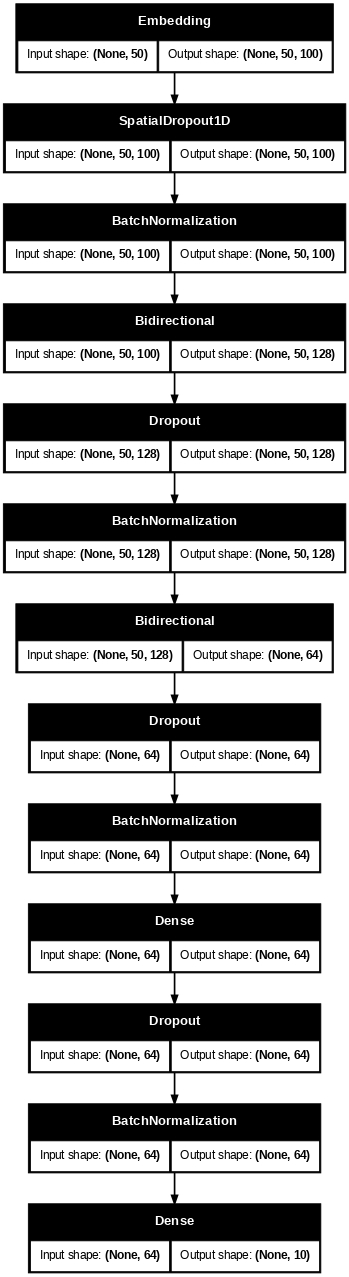

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.2236 - loss: 2.2750 - val_accuracy: 0.4167 - val_loss: 1.8276
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5480 - loss: 1.2089 - val_accuracy: 0.5909 - val_loss: 1.3028
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8236 - loss: 0.5601 - val_accuracy: 0.6515 - val_loss: 1.0483
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8903 - loss: 0.3603 - val_accuracy: 0.6717 - val_loss: 1.5235
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9116 - loss: 0.2920 - val_accuracy: 0.6338 - val_loss: 2.0329
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9214 - loss: 0.2783 - val_accuracy: 0.7172 - val_loss: 1.3473
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9208 - loss: 0.2848 - val_accuracy: 0.7323 - val_loss: 1.2336
Epoch 8/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9257 - loss: 0.2528 - val_a

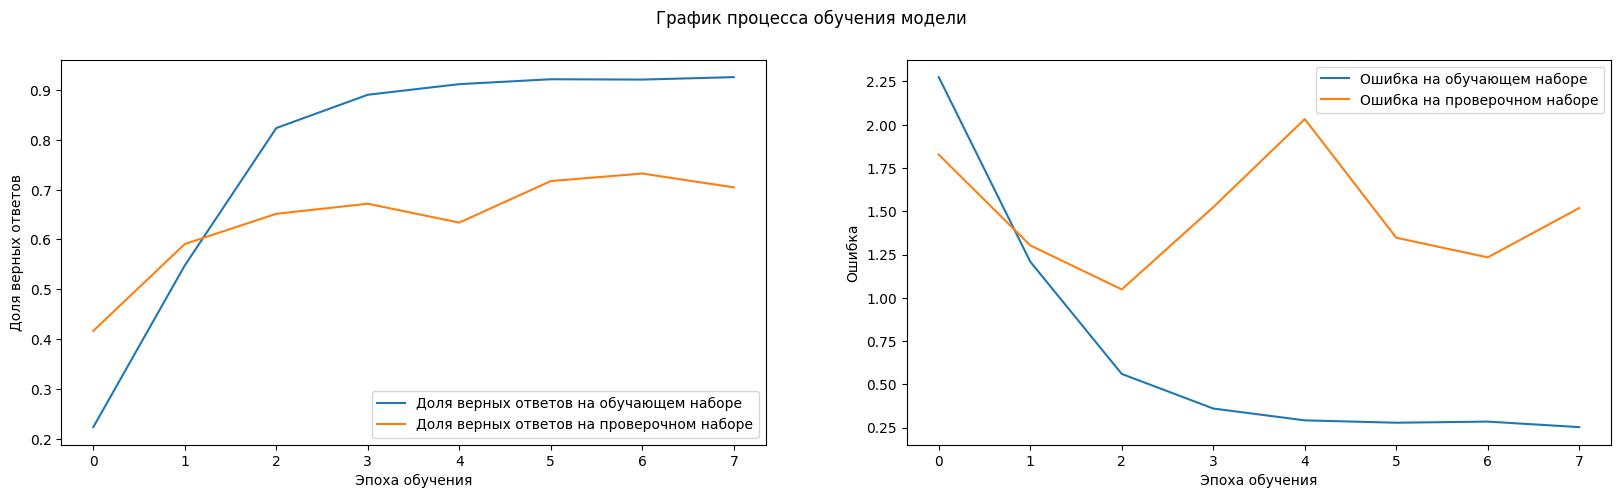

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


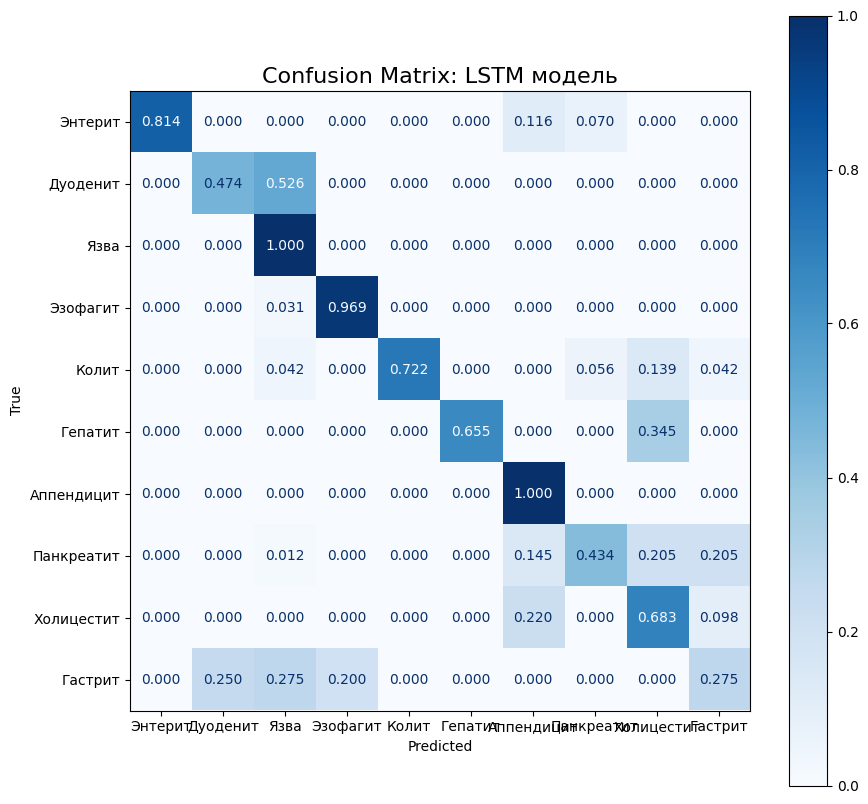

--------------------------------------------------------------------------------
Общая точность (Accuracy): 0.6515

Точность по классам (нормализованная):
  Энтерит         → 0.8140
  Дуоденит        → 0.4737
  Язва            → 1.0000
  Эзофагит        → 0.9688
  Колит           → 0.7222
  Гепатит         → 0.6552
  Аппендицит      → 1.0000
  Панкреатит      → 0.4337
  Холицестит      → 0.6829
  Гастрит         → 0.2750

Средняя точность по классам (macro): 0.7025


In [53]:
model_LSTM = Sequential([
    Input(shape=(WIN_SIZE,)),

    # Увеличенная размерность вектора до 100 для лучшего разделения смыслов
    Embedding(input_dim=VOCAB_SIZE, output_dim=100),

    # SpatialDropout1D эффективнее для текстовых данных, так как выбрасывает целые каналы
    SpatialDropout1D(0.3),
    BatchNormalization(),

    # Первый слой LSTM возвращает последовательность для второго слоя
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    BatchNormalization(),

    # Второй слой LSTM агрегирует информацию
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.3),

    BatchNormalization(),

    # Промежуточный мощный полносвязный слой
    Dense(64, activation='relu'),
    Dropout(0.4),
    BatchNormalization(),

    # Выходной слой на 10 классов
    Dense(CLASS_COUNT, activation='softmax')
])



compile_train_eval_model(model_LSTM,
                         x_train, y_train,
                         x_test, y_test,
                         epochs=EPOCHS,
                         optimizer='rmsprop',
                         batch_size=BATCH_SIZE,
                         class_labels=CLASS_LIST,
                         title='LSTM модель',)

In [54]:
model_LSTM.save('model_LSTM_pro.keras')